In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
import Post_Process_Run_n_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import Post_Process_Load_n_Plot as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

from pathlib import Path


In [ ]:
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__)

: 

In [ ]:
mesh_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Meshes")
# mesh_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&toroidal_pmls)/Meshes")
mesh_save_dir.mkdir(parents=True, exist_ok=True)

figure_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Figures")
# figure_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&toroidal_pmls)/Figures")
figure_save_dir.mkdir(parents=True, exist_ok=True)


solver.build_physics_Stix_B_field(lambda x, z: pp_run.create_density_profile(x, z, solver))
mesh = solver.build_mesh_with_PMLs()
# print('num_vertices = ', mesh.nv)

GF_E_field, _ = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh)


[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max resolution : 1.12760e-03 m
#DoFs = 517130 (= number of mesh points).


NgException: Trialfunction does not support BND-forms, maybe a Trace() operator is missing, type = FN5ngfem6DiffOpINS_12DiffOpIdEdgeILi2ENS_18HCurlFiniteElementILi2EEEEEEEvE

: 

In [ ]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&toroidal_pmls)/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260527_110512
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&toroidal_pmls)/Simulation_Results/Run_20260527_110512


: 

--- Extracting 2D Wave Map ---
params recover in run_2D_wave_map
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&toroidal_pmls)/Simulation_Results/Run_20260527_110512/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui
--- 2D Map saved to /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&toroidal_pmls)/Simulation_Results/Run_20260527_110512/Wave_Map_2D.h5 ---
--- Plotting 2D Map from /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&toroidal_pmls)/Simulation_Results/Run_20260527_110512/Wave_Map_2D.h5 ---


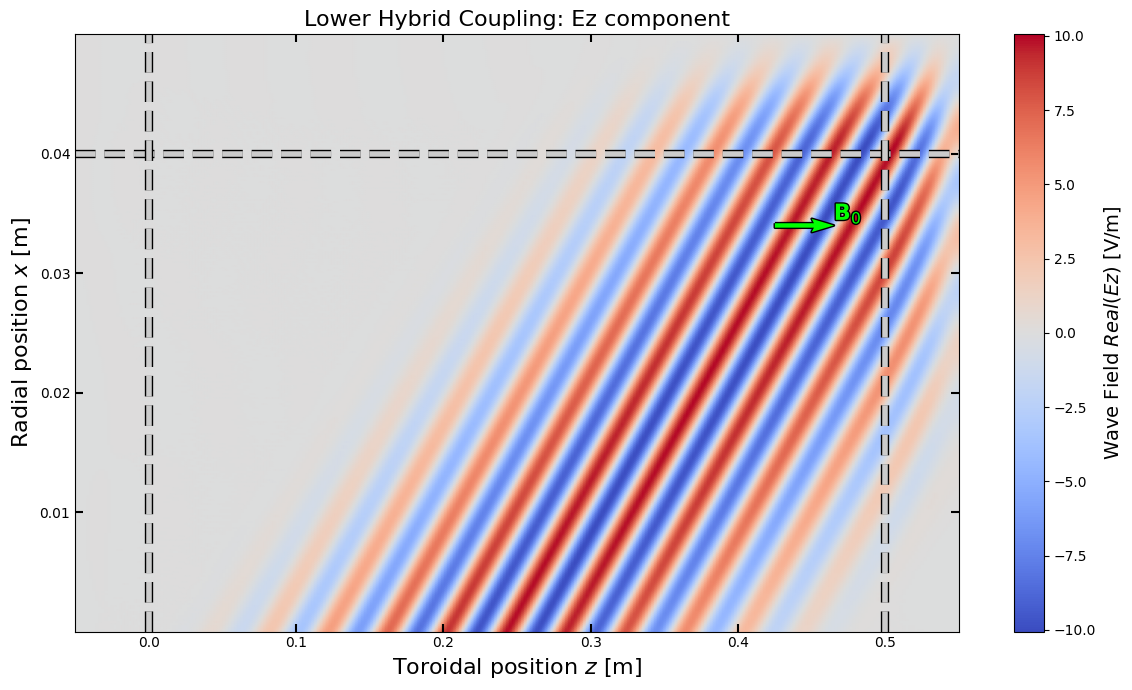

: 

In [ ]:
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path)
# --- Post-treatment: --- )
# Plot E field 2D map and save it in the same folder: Run_XXX 
pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, component='Ez', value_type='real', plot_e_vectors=False)

In [ ]:
# E_radial_profile_h5_filepath = pp_run.run_1D_radial_profile(mesh, GF_E_field, cfg, run_folder_tot_path)
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ex')
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ey')
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ez')

: 

In [ ]:
h5_file_path = pp_run.run_pml_scan_dataset(solver, cfg, run_folder_tot_path)

--- Initiating ULTIMATE 7D Sobol Data Lake: 4096 Simulations ---



Run 1/4096 | 
Lx_pml:2.4λ_perp, Sx_r:1.9, Sx_im:8.8, px:1.6
Lz_pml:8.7λ_para, Sz_r:10.0, Sz_im:1.1, pz:2.9, n//:1.44, ne:1.0e+18




NameError: name 'Lz_plasma_dynamic' is not defined

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from Post_Process_V3_Explore_Data import PMLDataExplorer

explorer_data_file = "/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260527_105312/PML_scan_all_param_dataset.h5"

# explorer_data_file = run_folder_tot_path + "/" + h5_file_path
print(explorer_data_file)
explorer = PMLDataExplorer(explorer_data_file)

display(explorer.df.describe())

/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260527_105312/PML_scan_all_param_dataset.h5
--- Loading Data Lake from /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260527_105312/PML_scan_all_param_dataset.h5 ---
[INFO] Data cleaned. Removed 440 failed simulations. Valid runs available: 3656


,B0,CPU_Time,D_stix,DoFs,Gamma_E_Radial,Lx_pml_ratio,P_stix,S_stix,Sx_im,Sx_r,lambda_para,lambda_perp,n_e,n_para,n_perp_minus,n_perp_plus,omega,px
count,3.656000e+03,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3.656000e+03,3656.000000,3656.000000,3656.000000,3.656000e+03,3656.000000
mean,3.700000e+00,2.268108,0.667999,88406.551969,0.146295,15.000084,-17.679081,1.018775,5.500144,2.500026,0.018080,0.006407,3.171154e+18,5.750728,0.003570,21.233654,2.324779e+10,2.250000
std,4.441500e-16,1.124483,0.540834,43395.891104,0.211938,2.887470,15.123218,0.015201,1.443854,0.865911,0.010515,0.005674,2.567474e+18,2.454062,0.048716,14.158558,7.630438e-06,0.433062
min,3.700000e+00,0.582184,0.105379,22259.000000,0.001513,10.002261,-57.838143,1.002962,3.000050,1.000103,0.008103,0.001123,5.002603e+17,1.501011,0.001000,1.748734,2.324779e+10,1.500289
25%,3.700000e+00,1.347122,0.222747,52508.500000,0.011708,12.500322,-26.843001,1.006261,4.250612,1.749934,0.010289,0.002796,1.057434e+18,3.625402,0.001000,10.425661,2.324779e+10,1.875124
50%,3.700000e+00,2.029984,0.471121,79869.500000,0.045233,15.000124,-12.173842,1.013242,5.500329,2.499823,0.014095,0.004621,2.236528e+18,5.748679,0.001000,17.532521,2.324779e+10,2.250102
75%,3.700000e+00,2.997639,0.995717,117663.750000,0.185618,17.499667,-5.228614,1.027986,6.748687,3.249677,0.022349,0.007772,4.726916e+18,7.874582,0.001000,28.974416,2.324779e+10,2.625049
max,3.700000e+00,8.005514,2.104161,225214.000000,0.979687,19.997644,-1.946688,1.059141,7.999589,3.999519,0.053980,0.046334,9.988972e+18,9.999088,1.294396,72.140106,2.324779e+10,2.999868


: 

[INFO] Applied filter 'Gamma_E_Radial < 0.05'. Points remaining: 1904


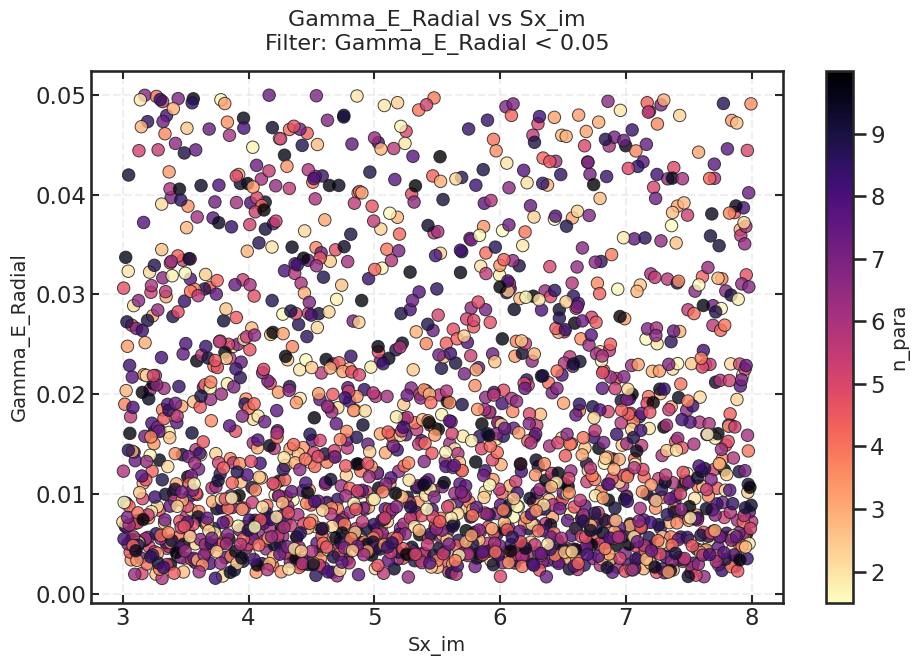

: 

In [ ]:
explorer.plot_universal_scatter(
    x_var = 'Sx_im', 
    y_var='Gamma_E_Radial', 
    color_var='n_para',
    filter_query="Gamma_E_Radial < 0.05"
)

<Axes: >

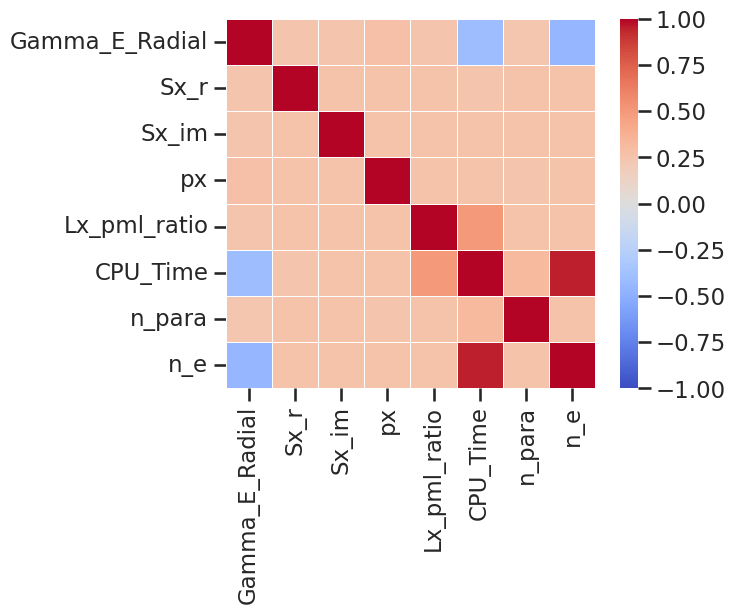

: 

In [ ]:
import seaborn as sns 
import pandas as pd
import h5py

#print(df.keys())
with h5py.File(explorer_data_file, 'r') as h5f:
    data_dict = {key: h5f[key][:] for key in h5f.keys()}

df = pd.DataFrame(data_dict)
df = df.query('Gamma_E_Radial < 0.99').copy()
 
corr_matrix = df[['Gamma_E_Radial', 'Sx_r', 'Sx_im', 'px', 'Lx_pml_ratio', 'CPU_Time', 'n_para', 'n_e']].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidth=.5)

In [ ]:
best_run_df = df.query('Gamma_E < 0.0003')
# sns.pairplot(best_run_df, vars=['Gamma_E', 'S_real', 'S_imag', 'L_pml_ratio', 'n_para', 'n_e'], diag_kind='kde', plot_kws={'alpha':0.6})
# plt.show()

: 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load clean dataset
clean_df = df.query("0 < Gamma_E < 0.90").copy()
clean_df['n_e_log'] = np.log10(clean_df['n_e']) 
features = ['S_imag', 'L_pml_ratio', 'S_real', 'p_degree', 'n_para', 'n_e_log']

X = clean_df[features].values              # X = inputs of the model 
Y = np.log10(clean_df['Gamma_E'].values)   # Y = outputs
 
print(f"Valid runs for training: {len(clean_df)}")

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, train_size=2000, random_state=42)

# Generating the kernel
physics_kernel = C(1.0) * Matern(length_scale=[1.0] * len(features), nu=2.5)
noise_kernel = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1.0))
full_kernel = physics_kernel + noise_kernel

# GPR Configuration
gpr = GaussianProcessRegressor(
    kernel=full_kernel, 
    n_restarts_optimizer=10, 
    normalize_y=True, 
    random_state=42
)

print("Training Noise-Adaptive GPR (This may take 1-2 minutes)...")
gpr.fit(X_train, y_train)

# 8. Validation
y_pred_test = gpr.predict(X_test)
r2 = r2_score(y_test, y_pred_test)

print(f"\n[VALIDATION] GPR R^2 Score on unseen data: {r2:.4f}")

: 

In [ ]:
if r2 > 0.85:
    print("\n[SUCCESS] The model successfully mapped the physics and ignored the mode-mixing noise.")
    
    # Print the learned length scales
    learned_scales = gpr.kernel_.k1.k2.length_scale
    print("\nLearned Length Scales (Smaller = Higher Physical Impact):")
    for name, scale in zip(features, learned_scales):
        print(f"{name:12}: {scale:.2f}")

: 

In [ ]:
# mesh_conv_h5_filepath = pp_run.run_mesh_convergence(solver, cfg, run_folder_tot_path)

: 

In [ ]:
# pp_plot.plot_mesh_convergence(mesh_conv_h5_filepath, run_folder_tot_path)

: 

In [ ]:
# Pour faire des boucles sur les params de config_dict

cfg.DOMAIN['Lx_plasma'] = 30.
print(cfg.DOMAIN['Lx_plasma'] )



: 